# Word Frequency Analysis with Apache Beam

In this notebook, we build an Apache Beam pipeline that performs **word frequency analysis** on Shakespeare's *Romeo and Juliet*. The pipeline runs locally using the [DirectRunner](https://beam.apache.org/documentation/runners/direct/).

Compared to a basic word count, this pipeline:
- **Normalizes case** (so "Romeo", "ROMEO", and "romeo" are counted together)
- **Filters stop words** (removes common words like "the", "and", "of")
- **Visualizes the top 20 words** as a bar chart
- **Prints summary statistics** (unique words, total count, top/bottom 5)
- **Exports results to CSV** for further analysis

# Setup

First, make sure you have installed the dependencies from `requirements.txt` (`apache-beam`, `pandas`, `matplotlib`). The text of *Romeo and Juliet* is bundled in `data/`.

In [1]:
# Run and print a shell command.
def run(cmd):
  print('>> {}'.format(cmd))
  !{cmd}
  print('')

# Verify the input data file is present (bundled in the repo).
import os
assert os.path.exists('data/romeo_and_juliet.txt'), "data/romeo_and_juliet.txt not found!"
print("data/romeo_and_juliet.txt is ready ({:.1f} KB)".format(
    os.path.getsize('data/romeo_and_juliet.txt') / 1024))

data/romeo_and_juliet.txt is ready (165.5 KB)


# Word Frequency Pipeline

The pipeline reads every line from `data/`, tokenizes words, lowercases them, removes stop words, then counts occurrences.

In [2]:
import apache_beam as beam
import re

inputs_pattern = 'data/*.txt'
outputs_prefix = 'outputs/part'

STOP_WORDS = {'the', 'and', 'of', 'to', 'a', 'in', 'i', 'is', 'it', 'that',
              'my', 'with', 'not', 'for', 'you', 'this', 'but', 'his', 'be',
              'he', 'your', 'her', 'me', 'have', 'do', 'no', 'so', 'what',
              'will', 'we', 'are', 'shall', 'as', 'all', 'if', 'was', 'on',
              'thy', 'or', 'at', 'by', 'from', 'our', 'an', 'them', 'had'}

with beam.Pipeline() as pipeline:
  word_counts = (
      pipeline

      | 'Read lines' >> beam.io.ReadFromText(inputs_pattern)

      | 'Find words' >> beam.FlatMap(lambda line: re.findall(r"[a-zA-Z']+", line))

      | 'Lowercase' >> beam.Map(str.lower)

      | 'Remove stop words' >> beam.Filter(lambda word: word not in STOP_WORDS)

      | 'Pair words with 1' >> beam.Map(lambda word: (word, 1))

      | 'Group and sum' >> beam.CombinePerKey(sum)
  )

  (
      word_counts
      | 'Format results' >> beam.Map(lambda word_count: str(word_count))
      | 'Write results' >> beam.io.WriteToText(outputs_prefix)
  )

# Preview the first 20 results.
run('head -n 20 {}-00000-of-*'.format(outputs_prefix))

/Users/gurpuramit/Desktop/MLOps/Labs/Data_Labs/Apache_Beam_Labs/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


>> head -n 20 outputs/part-00000-of-*


('project', 89)
('gutenberg', 99)
('ebook', 13)
('romeo', 320)
('juliet', 194)
('use', 28)
('anyone', 5)
('anywhere', 3)
('united', 15)
('states', 19)
('most', 22)
('other', 35)
('parts', 4)
('world', 21)
('cost', 4)
('almost', 5)
('restrictions', 2)
('whatsoever', 2)
('may', 63)
('copy', 12)


# Top 20 Words Visualization

Read back the pipeline output, sort by frequency, and plot the top 20 content words.

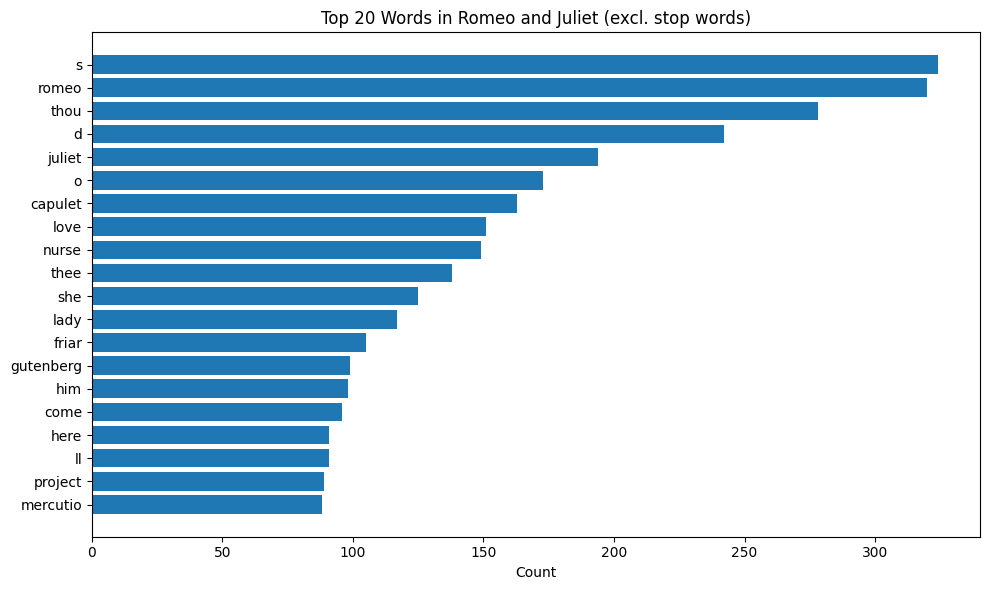

In [3]:
import glob
import ast
import matplotlib.pyplot as plt

output_file = glob.glob('outputs/part-00000-of-*')[0]

results = []
with open(output_file) as f:
    for line in f:
        word, count = ast.literal_eval(line.strip())
        results.append((word, count))

top20 = sorted(results, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*top20)

plt.figure(figsize=(10, 6))
plt.barh(words[::-1], counts[::-1])
plt.xlabel('Count')
plt.title('Top 20 Words in Romeo and Juliet (excl. stop words)')
plt.tight_layout()
plt.show()

# Summary Statistics

Key metrics from the word frequency analysis.

In [4]:
total_unique = len(results)
total_occurrences = sum(c for _, c in results)
avg_freq = total_occurrences / total_unique

sorted_results = sorted(results, key=lambda x: x[1], reverse=True)

print(f"Total unique words:     {total_unique:,}")
print(f"Total word occurrences: {total_occurrences:,}")
print(f"Average frequency:      {avg_freq:.1f}")
print(f"\nTop 5:    {sorted_results[:5]}")
print(f"Bottom 5: {sorted_results[-5:]}")

Total unique words:     3,951
Total word occurrences: 18,962
Average frequency:      4.8

Top 5:    [('s', 324), ('romeo', 320), ('thou', 278), ('d', 242), ('juliet', 194)]
Bottom 5: [('facility', 1), ('includes', 1), ('produce', 1), ('subscribe', 1), ('newsletter', 1)]


# Export to CSV

Write the full word frequency table to a CSV file sorted by descending count.

In [5]:
import pandas as pd

df = pd.DataFrame(sorted_results, columns=['word', 'count'])
csv_path = 'outputs/word_counts.csv'
df.to_csv(csv_path, index=False)
print(f"Exported {len(df)} words to {csv_path}")
df.head(10)

Exported 3951 words to outputs/word_counts.csv


,word,count
0,s,324
1,romeo,320
2,thou,278
3,d,242
4,juliet,194
5,o,173
6,capulet,163
7,love,151
8,nurse,149
9,thee,138
